In [31]:
import os
import sys
from pathlib import Path

# Adicionar o diretório pai ao path para importar functions_.py
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl
import seaborn as sns
import joblib

# Importar funções do arquivo functions_.py
from functions_ import *
from UQpy.distributions import Uniform, JointIndependent

# Configuração de estilo dos gráficos
mpl.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.unicode_minus': False,
    'figure.dpi': 100
})

# 2. CARREGAMENTO DO MODELO DE CARBONATAÇÃO

In [32]:
# Caminho para o modelo treinado
name_best_model = r'D:\\Documentos\\ic_victor\\beam_problem_1\\model_NeuralNetwork_MLP_fold_4.pkl'

# Carregar o modelo
model = joblib.load(name_best_model)

print("Modelo de carbonatação carregado com sucesso!")
print(f"   Features esperadas: {model.feature_names_in_}")

Modelo de carbonatação carregado com sucesso!
   Features esperadas: ['CO2 (%)' 'fc (MPa)' 'RH (%)' 'Type of cement' 'Exposure conditions'
 't (years)']


# 3. DEFINIÇÃO DA VIGA DE REFERÊNCIA

In [33]:
# Define as propriedades geométricas, materiais, carregamentos e condições de exposição da viga.
# Os valores aqui são determinísticos e serão sobrescritos pelas amostras aleatórias.

# Propriedades geométricas
geo = {
    'b_w [m]': 0.20,           # Largura da viga [m]
    'h [m]': 0.25,             # Altura da viga [m]
    'l [m]': 6.00,             # Vão da viga [m]
    'n bars': 4,               # Número de barras de aço
    'phi [m]': 0.0125,         # Diâmetro das barras [m] (12.5 mm)
    'ratio d/h': 0.84,         # Razão entre altura útil e altura total
    'cover [m]': 0.015         # Cobrimento nominal [m] (será sobrescrito)
}

# Propriedades dos materiais
mat = {
    'f_yk [kPa]': 500E3,       # Resistência característica do aço [kPa]
    'f_ck [kPa]': 25E3,        # Resistência característica do concreto [kPa] (será sobrescrito)
    'e_s [kPa]': 200E6,        # Módulo de elasticidade do aço [kPa]
    'gamma_c': 1.0,            # Coeficiente de segurança do concreto
    'gamma_s': 1.0,            # Coeficiente de segurança do aço
    'Type of cement': 2        # Tipo de cimento (2 = CPIV)
}

# Carregamentos
load = {
    'g_k [kN/m]': 5.0,         # Carga permanente [kN/m]
    'q_k [kN/m]': 2.0,         # Carga variável [kN/m]
    'gamma_g': 1.0,            # Coeficiente de segurança para carga permanente
    'gamma_q': 1.0             # Coeficiente de segurança para carga variável
}

# Condições de exposição
expo = {
    'temp [°C]': 25.0,                 # Temperatura ambiente [°C]
    'Relative humidity [%]': 65.0,     # Umidade relativa [%] (será sobrescrita)
    'Installation year': 2000,         # Ano de instalação da estrutura
    'Exposure conditions': 3,          # Condição de exposição (2 = PEA - External Protected)
    'i_corr_20': 2.3                   # Índice de corrosão a 20°C [μA/cm²]
}

# Criar a viga de referência
beam_ref = Beam(geo, mat, load, expo)

# 4. DEFINIÇÃO DAS VARIÁVEIS ALEATÓRIAS

In [34]:
# Define as distribuições de probabilidade para as variáveis de entrada:
# - Cobrimento (cover)
# - Resistência à compressão do concreto (fck)
# - Umidade relativa (RH)

# %%
# Número de amostras
n_samples = 100              # Número de amostras de projeto
n_latent_samples = 1000       # Número de amostras latentes por amostra de projeto

# Distribuições das variáveis aleatórias
cover_dist = Uniform(loc=0.015, scale=0.005)     # Cobrimento: 15-20 mm
fck_dist = Uniform(loc=25E3, scale=50E3 - 25E3) # Resistência: 25-50 MPa
rh_dist = Uniform(loc=20, scale=60)             # Umidade: 20-80%

# Distribuição conjunta
joint = JointIndependent(marginals=[cover_dist, fck_dist, rh_dist])

# Gerar amostras
x = joint.rvs(n_samples)

print("Amostras geradas com sucesso!")
print(f"   Número de amostras de projeto: {n_samples}")
print(f"   Número de amostras latentes por projeto: {n_latent_samples}")
print(f"   Total de simulações: {n_samples * n_latent_samples}")
print("\nEstatísticas das amostras:")
print(f"   Cover: {x[:, 0].min()*1000:.1f} - {x[:, 0].max()*1000:.1f} mm (média: {x[:, 0].mean()*1000:.1f} mm)")
print(f"   fck:   {x[:, 1].min()/1000:.1f} - {x[:, 1].max()/1000:.1f} MPa (média: {x[:, 1].mean()/1000:.1f} MPa)")
print(f"   RH:    {x[:, 2].min():.1f} - {x[:, 2].max():.1f}% (média: {x[:, 2].mean():.1f}%)")

Amostras geradas com sucesso!
   Número de amostras de projeto: 100
   Número de amostras latentes por projeto: 1000
   Total de simulações: 100000

Estatísticas das amostras:
   Cover: 15.0 - 20.0 mm (média: 17.7 mm)
   fck:   25.2 - 49.7 MPa (média: 37.9 MPa)
   RH:    21.2 - 79.6% (média: 47.4%)


# 5. DEFINIÇÃO DA FUNÇÃO DE ESTADO (DURABILIDADE)

In [35]:
# Esta seção define a função que calcula o estado limite para a análise de durabilidade,
# seguindo a abordagem do orientador: g = cover - carbonation_depth.
# A função já está definida no arquivo functions_.py como `state_limit_function_time_durability`.

# %%
# Função já definida em functions_.py
# Para referência, a função implementa:
#   1. Geração de variáveis latentes de umidade (fatores multiplicativos)
#   2. Cálculo da profundidade de carbonatação para cada amostra
#   3. Cálculo do estado limite: g = cover - carbonation_depth
#   4. Fitting do GLAM para os parâmetros lambda

# 6. AVALIAÇÃO DA FUNÇÃO DE ESTADO PARA DIFERENTES TEMPOS

In [36]:
# Executa a análise para diferentes tempos de vida útil (0 a 100 anos, passo de 10 anos).

# %%
# Tempos a serem analisados
times = np.arange(0, 101, 10)
results = {}

print("="*60)
print("INICIANDO ANÁLISE DE DURABILIDADE")
print("="*60)

for t in times:
    print(f'\n{"-"*40}')
    print(f'PROCESSANDO TEMPO: {t} anos')
    print(f'{"-"*40}')
    
    df = state_limit_function_time_durability(
        x=x,
        names_x_variables=["cover", "fck", "rh"],
        carb_model=model,
        cement_type=2,
        installation_year=2000,
        exposure_conditions=2,
        time_step=t,
        n_latent_samples=n_latent_samples,
        verbose=True
    )
    
    results[t] = df
    print(f'\nTempo {t} anos concluído!')
    print(f'   Dimensões do DataFrame: {df.shape}')
    print(f'   Colunas: {list(df.columns)}')

print("\n" + "="*60)
print("ANÁLISE CONCLUÍDA PARA TODOS OS TEMPOS!")
print("="*60)

INICIANDO ANÁLISE DE DURABILIDADE

----------------------------------------
PROCESSANDO TEMPO: 0 anos
----------------------------------------
Processing sample 1/100
  Sample 1:
    P(g < 0) = 0.0000
    Mean carbonation depth = 0.84 mm
    GLAM converged: True
Processing sample 2/100
  Sample 2:
    P(g < 0) = 0.0000
    Mean carbonation depth = 0.09 mm
    GLAM converged: True
Processing sample 3/100
  Sample 3:
    P(g < 0) = 0.0000
    Mean carbonation depth = 1.16 mm
    GLAM converged: True
Processing sample 4/100
  Sample 4:
    P(g < 0) = 0.0000
    Mean carbonation depth = 0.58 mm
    GLAM converged: True
Processing sample 5/100
  Sample 5:
    P(g < 0) = 0.0000
    Mean carbonation depth = 0.58 mm
    GLAM converged: True
Processing sample 6/100
  Sample 6:
    P(g < 0) = 0.0000
    Mean carbonation depth = 0.29 mm
    GLAM converged: True
Processing sample 7/100
  Sample 7:
    P(g < 0) = 0.0000
    Mean carbonation depth = 0.10 mm
    GLAM converged: True
Processing sample

# 7. ORGANIZAÇÃO DOS RESULTADOS E EXTRAÇÃO DOS LAMBDAS

In [37]:
# Organiza os dados por tempo e extrai os parâmetros GLAM (lambdas) para cada tempo.

# %%
time = sorted(results.keys())

gs = []                    # Lista de DataFrames por tempo
lambdas = []               # Lista de parâmetros GLAM
stats_summary = []         # Lista para estatísticas resumidas

print("\nExtraindo estatísticas e parâmetros GLAM...")

for t in time:
    df = results[t]
    gs.append(df)
    
    # Extrair lambdas (média por amostra)
    lambda_cols = ['lambda 1', 'lambda 2', 'lambda 3', 'lambda 4']
    if all(col in df.columns for col in lambda_cols):
        lam_mean = []
        for col in lambda_cols:
            valid_vals = df[col][~np.isnan(df[col])]
            if len(valid_vals) > 0:
                lam_mean.append(valid_vals.mean())
            else:
                lam_mean.append(np.nan)
        lambdas.append(lam_mean)
        
        stats_summary.append({
            'time': t,
            'n_samples': len(df),
            'P_failure': np.mean(df['g'] < 0),
            'g_mean': df['g'].mean(),
            'g_std': df['g'].std(),
            'g_min': df['g'].min(),
            'g_max': df['g'].max(),
            'carb_depth_mean': df['Carbonation_depth_mm'].mean(),
            'carb_depth_std': df['Carbonation_depth_mm'].std(),
            'lambda_1_mean': lam_mean[0],
            'lambda_2_mean': lam_mean[1],
            'lambda_3_mean': lam_mean[2],
            'lambda_4_mean': lam_mean[3]
        })
    else:
        lambdas.append([np.nan, np.nan, np.nan, np.nan])
        stats_summary.append({
            'time': t,
            'n_samples': len(df),
            'P_failure': np.mean(df['g'] < 0),
            'g_mean': df['g'].mean(),
            'g_std': df['g'].std(),
            'g_min': df['g'].min(),
            'g_max': df['g'].max(),
            'carb_depth_mean': df['Carbonation_depth_mm'].mean(),
            'carb_depth_std': df['Carbonation_depth_mm'].std(),
            'lambda_1_mean': np.nan,
            'lambda_2_mean': np.nan,
            'lambda_3_mean': np.nan,
            'lambda_4_mean': np.nan
        })

lambdas = np.array(lambdas)
stats_df = pd.DataFrame(stats_summary)

print("\nEstatísticas extraídas!")
print("\nTabela resumo:")
print(stats_df.round(4).to_string())



Extraindo estatísticas e parâmetros GLAM...

Estatísticas extraídas!

Tabela resumo:
    time  n_samples  P_failure   g_mean    g_std    g_min    g_max  carb_depth_mean  carb_depth_std  lambda_1_mean  lambda_2_mean  lambda_3_mean  lambda_4_mean
0      0     100000     0.0000  16.9073   1.5953  12.7565  19.9984           0.7868          0.8528        16.9051        57.1899         1.1132         3.1478
1     10     100000     0.0123   9.8382   3.5999  -1.1452  18.0446           7.8559          3.4742         9.7929         4.5257         0.6606         0.0582
2     20     100000     0.1019   6.6119   5.0665  -8.4705  16.9688          11.0822          5.0404         6.5341         3.6074         1.0887         0.6981
3     30     100000     0.2094   4.0174   6.1201 -14.4064  15.9685          13.6767          6.1364         3.9510         2.8545         0.5043         0.1050
4     40     100000     0.3287   1.8886   7.0288 -19.9889  15.4238          15.8055          7.0719         1.8091

# 8. GRÁFICO KDE - EVOLUÇÃO DO ESTADO LIMITE g(t)


Gerando gráfico KDE da evolução de g(t)...


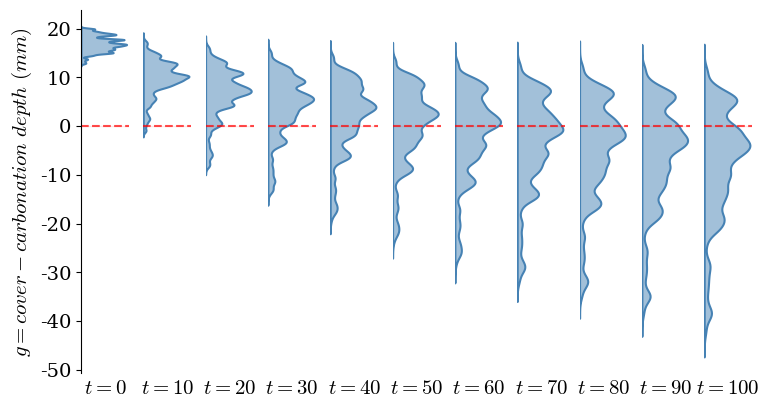

Gráfico salvo como 'z_time-lapse_g_analysis_durability.png'


In [38]:
# Visualiza a evolução da função de estado limite g(t) = cover - carbonation_depth ao longo do tempo,
# com destaque para a região de falha (g < 0).

# %%
# Configurações da figura
dpi = 600
name = 'time-lapse_g_analysis_durability'

b_cm_individual = 2.0
h_cm = 12
inches_to_cm = 1 / 2.54

n_plots = len(time)
b_input_total = (b_cm_individual * n_plots) * inches_to_cm
h_input = h_cm * inches_to_cm

label_y = '$g = cover - carbonation\ depth\ (mm)$'
size_label = 15
size_axis = 14
color = 'steelblue'
alpha = 0.5

label_x = '$t (anos)$'
size_label = 15
size_axis = 14
color = 'steelblue'
alpha = 0.5

print("\nGerando gráfico KDE da evolução de g(t)...")

# Criar figura
fig, axes = plt.subplots(
    nrows=1, 
    ncols=n_plots, 
    sharey=True, 
    figsize=(b_input_total, h_input)
)

plt.subplots_adjust(wspace=0.3)

# Loop para cada tempo
for i, ax in enumerate(axes):
    
    current_data = gs[i]
    
    # KDE plot com seaborn
    sns.kdeplot(
        y=current_data['g'], 
        fill=True, 
        alpha=alpha, 
        ax=ax, 
        color=color,
        linewidth=1.5
    )
    
    # Linha de falha (g = 0)
    ax.axhline(0, linestyle='--', linewidth=1.5, color='red', alpha=0.7)
    
    # Destacar região de falha
    ax.axhspan(-np.inf, 0, alpha=0.1, color='red')
    
    # Configurar eixo x
    ax.set_xlabel(f'$t={int(time[i])}$', fontsize=size_label)
    ax.tick_params(axis='x', bottom=False, labelbottom=False)
    
    # Remover bordas
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    # Configurar eixo y (apenas para o primeiro subplot)
    if i == 0:
        ax.set_ylabel(label_y, fontsize=size_label)
        ax.tick_params(axis='y', labelsize=size_axis)
    else:
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', left=False)
        ax.set_ylabel('')

# Salvar figura
fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

print(f"Gráfico salvo como 'z_{name}.png'")

# 9. GRÁFICO DOS LAMBDAS - EVOLUÇÃO TEMPORAL


Gerando gráfico de evolução dos lambdas...


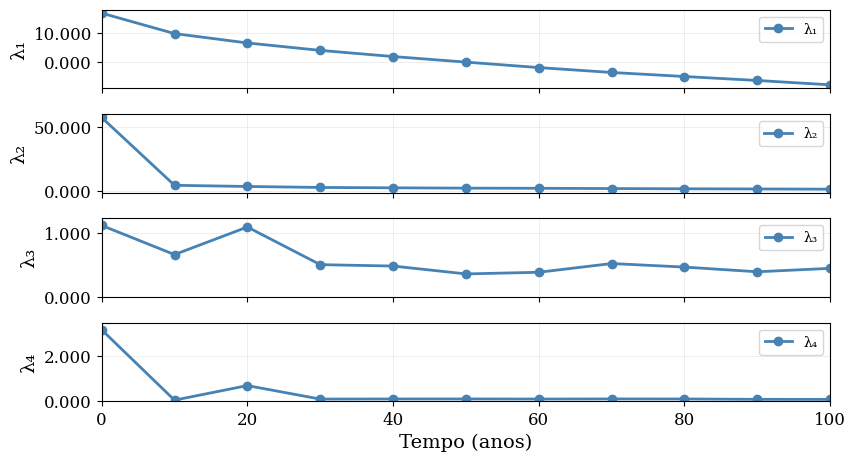

Gráfico salvo como 'z_lambdas_evolution_durability.png'


In [39]:
# Visualiza a evolução dos parâmetros lambda do GLAM ao longo do tempo.

# %%
# Preparar dados
y1 = lambdas[:, 0]
y2 = lambdas[:, 1]
y3 = lambdas[:, 2]
y4 = lambdas[:, 3]

data = [
    {'x': time, 'y': y1, 'label': 'λ₁'},
    {'x': time, 'y': y2, 'label': 'λ₂'},
    {'x': time, 'y': y3, 'label': 'λ₃'},
    {'x': time, 'y': y4, 'label': 'λ₄'}
]

# Configurações
label_x = 'Tempo (anos)'
size_label = 14
size_axis = 12
size_line = 2
style_line = '-'
color_line = 'steelblue'
marker = 'o'
size_marker = 6

print("\nGerando gráfico de evolução dos lambdas...")

# Figura com 4 subplots
fig, axes = plt.subplots(
    nrows=4, 
    ncols=1, 
    sharex=True, 
    figsize=(b_input_total, h_input)
)

# Plot
for ax, dataset in zip(axes, data):
    # Remover NaNs para plot
    valid_idx = ~np.isnan(dataset['y'])
    x_valid = np.array(dataset['x'])[valid_idx]
    y_valid = np.array(dataset['y'])[valid_idx]
    
    ax.plot(
        x_valid, y_valid,
        marker=marker,
        markersize=size_marker,
        linewidth=size_line,
        linestyle=style_line,
        color=color_line,
        label=dataset['label']
    )
    
    ax.tick_params(axis='both', which='major', labelsize=size_axis)
    ax.set_ylabel(dataset['label'], fontsize=size_label)
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
    ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.3)
    ax.legend(loc='best', fontsize=10)

# Ajuste de limites (específico para λ₃ e λ₄)
if len(y3[~np.isnan(y3)]) > 0:
    axes[2].set_ylim(0.0, max(0.3, y3.max() * 1.1))
if len(y4[~np.isnan(y4)]) > 0:
    axes[3].set_ylim(0.0, max(0.5, y4.max() * 1.1))

axes[-1].set_xlim(min(time), max(time))
axes[-1].set_xlabel(label_x, fontsize=size_label)

plt.tight_layout()
fig.savefig(f'z_lambdas_evolution_durability.png', dpi=dpi, bbox_inches='tight')
plt.show()

print(f"Gráfico salvo como 'z_lambdas_evolution_durability.png'")

# 10. GRÁFICO ADICIONAL: EVOLUÇÃO DA PROBABILIDADE DE FALHA

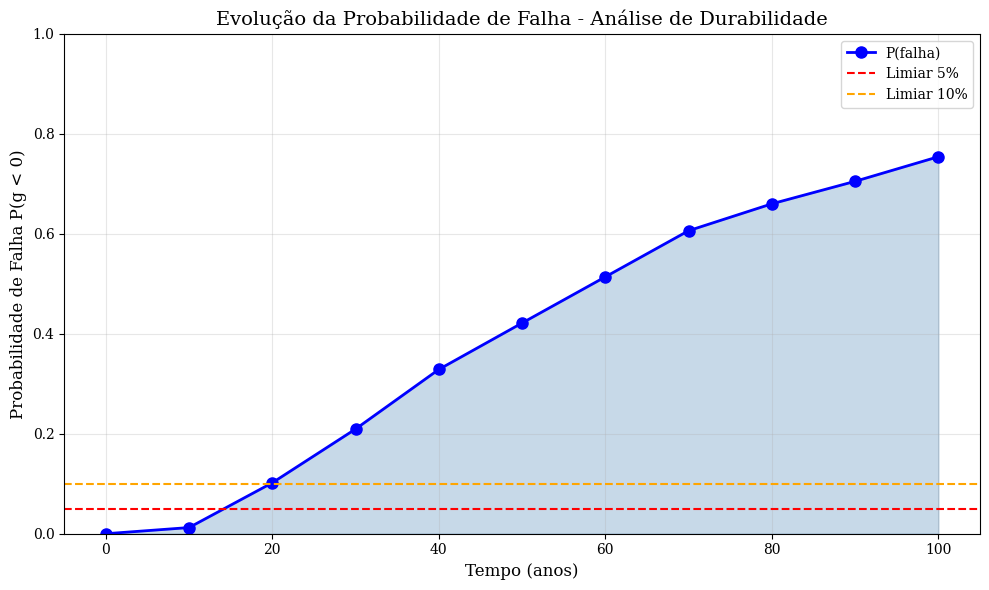

Gráfico salvo como 'probabilidade_falha_durability.png'


In [40]:
# Visualiza como a probabilidade de falha P(g < 0) evolui ao longo do tempo,
# identificando os tempos em que ultrapassa os limiares de 5% e 10%.

# %%
fig, ax = plt.subplots(figsize=(10, 6))

tempos = stats_df['time'].values
prob_falha = stats_df['P_failure'].values

ax.plot(tempos, prob_falha, 'b-o', linewidth=2, markersize=8, label='P(falha)')
ax.axhline(y=0.05, color='r', linestyle='--', linewidth=1.5, label='Limiar 5%')
ax.axhline(y=0.10, color='orange', linestyle='--', linewidth=1.5, label='Limiar 10%')
ax.fill_between(tempos, 0, prob_falha, alpha=0.3, color='steelblue')

ax.set_xlabel('Tempo (anos)', fontsize=12)
ax.set_ylabel('Probabilidade de Falha P(g < 0)', fontsize=12)
ax.set_title('Evolução da Probabilidade de Falha - Análise de Durabilidade', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0, max(1.0, prob_falha.max() * 1.1))

plt.tight_layout()
plt.savefig('probabilidade_falha_durability.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico salvo como 'probabilidade_falha_durability.png'")

# 11. GRÁFICO ADICIONAL: EVOLUÇÃO DA PROFUNDIDADE DE CARBONATAÇÃO

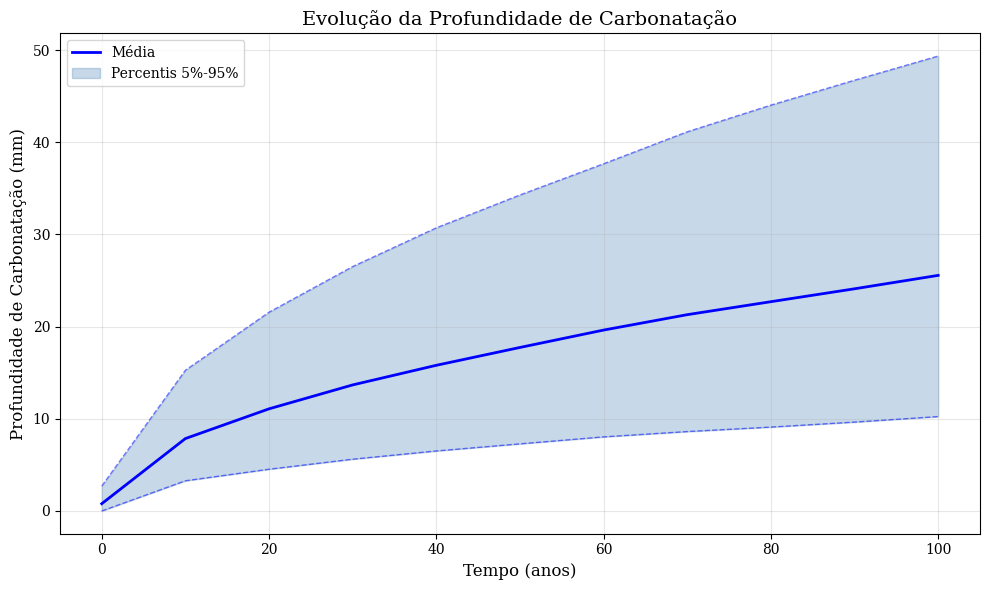

Gráfico salvo como 'carbonation_depth_evolution.png'


In [41]:
# Visualiza a evolução da profundidade de carbonatação ao longo do tempo,
# com a média e os percentis 5% e 95% para representar a incerteza.

# %%
fig, ax = plt.subplots(figsize=(10, 6))

# Calcular percentis para cada tempo
carb_percentiles = []
for t in tempos:
    df_t = results[t]
    depths = df_t['Carbonation_depth_mm'].values
    carb_percentiles.append({
        'mean': depths.mean(),
        'p5': np.percentile(depths, 5),
        'p95': np.percentile(depths, 95),
        'median': np.median(depths),
        'std': depths.std()
    })

carb_mean = [p['mean'] for p in carb_percentiles]
carb_p5 = [p['p5'] for p in carb_percentiles]
carb_p95 = [p['p95'] for p in carb_percentiles]

ax.plot(tempos, carb_mean, 'b-', linewidth=2, label='Média')
ax.fill_between(tempos, carb_p5, carb_p95, alpha=0.3, color='steelblue', label='Percentis 5%-95%')
ax.plot(tempos, carb_p5, 'b--', linewidth=1, alpha=0.5)
ax.plot(tempos, carb_p95, 'b--', linewidth=1, alpha=0.5)

ax.set_xlabel('Tempo (anos)', fontsize=12)
ax.set_ylabel('Profundidade de Carbonatação (mm)', fontsize=12)
ax.set_title('Evolução da Profundidade de Carbonatação', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('carbonation_depth_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico salvo como 'carbonation_depth_evolution.png'")


# 12. GRÁFICO ADICIONAL: RELAÇÃO COBRIMENTO vs PROFUNDIDADE

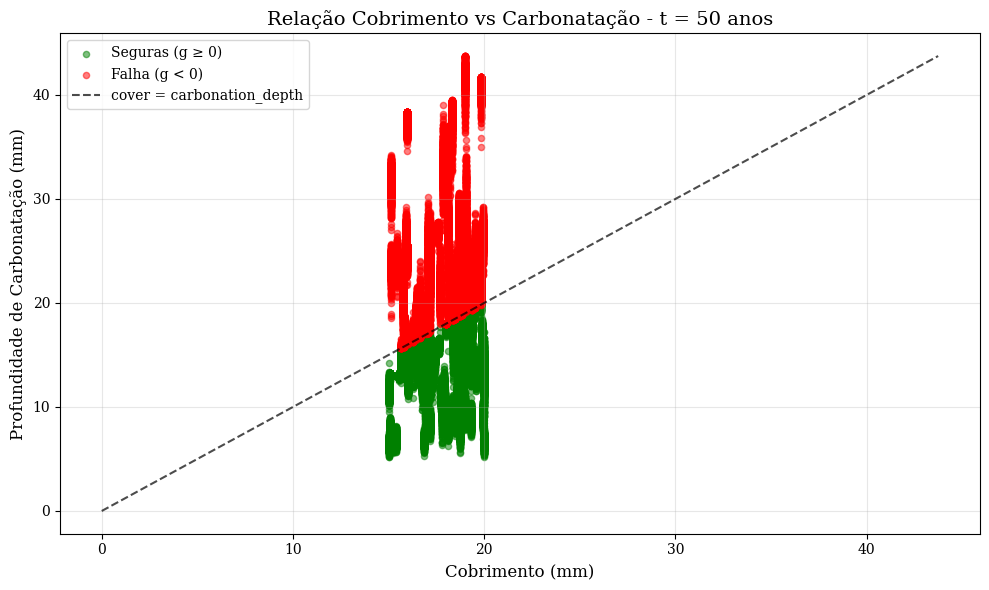

Gráfico salvo como 'cover_vs_carbonation.png'
   Amostras seguras: 57848
   Amostras em falha: 42152


In [42]:
# Visualiza a relação entre o cobrimento e a profundidade de carbonatação em t=50 anos,
# identificando as amostras que falham (g < 0).

# %%
# Selecionar tempo de análise
t_analysis = 50

if t_analysis in results:
    df_t50 = results[t_analysis]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Separar amostras seguras e falhas
    safe = df_t50[df_t50['g'] >= 0]
    failed = df_t50[df_t50['g'] < 0]
    
    # Plot
    ax.scatter(safe['Cover_mm'], safe['Carbonation_depth_mm'], 
               alpha=0.5, s=20, c='green', label='Seguras (g ≥ 0)')
    ax.scatter(failed['Cover_mm'], failed['Carbonation_depth_mm'], 
               alpha=0.5, s=20, c='red', label='Falha (g < 0)')
    
    # Linha de igualdade (cover = carbonation_depth)
    x_line = np.linspace(0, max(df_t50['Cover_mm'].max(), df_t50['Carbonation_depth_mm'].max()), 100)
    ax.plot(x_line, x_line, 'k--', linewidth=1.5, alpha=0.7, label='cover = carbonation_depth')
    
    ax.set_xlabel('Cobrimento (mm)', fontsize=12)
    ax.set_ylabel('Profundidade de Carbonatação (mm)', fontsize=12)
    ax.set_title(f'Relação Cobrimento vs Carbonatação - t = {t_analysis} anos', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('cover_vs_carbonation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Gráfico salvo como 'cover_vs_carbonation.png'")
    print(f"   Amostras seguras: {len(safe)}")
    print(f"   Amostras em falha: {len(failed)}")
else:
    print(f"Tempo {t_analysis} não encontrado nos resultados")


# 13. RESUMO FINAL E ESTATÍSTICAS

In [43]:
# Apresenta um resumo completo da análise com as principais estatísticas e conclusões.

print("RESUMO FINAL - ANÁLISE DE DURABILIDADE")

print(f"\n CONFIGURAÇÃO DA ANÁLISE:")
print(f"   • Total de simulações: {n_samples * n_latent_samples * len(times):,}")
print(f"   • Tempos analisados: {times} anos")

print(f"\n EVOLUÇÃO DA PROBABILIDADE DE FALHA:")
for i, t in enumerate(tempos):
    print(f"   • t = {t:3d} anos: {prob_falha[i]:.4f} ({prob_falha[i]*100:.2f}%)")

# Identificar vida útil (tempo para P(f) > 5% e 10%)
vida_util_5 = None
vida_util_10 = None
for t, pf in zip(tempos, prob_falha):
    if vida_util_5 is None and pf >= 0.05:
        vida_util_5 = t
    if vida_util_10 is None and pf >= 0.10:
        vida_util_10 = t

print(f"\n VIDA ÚTIL ESTIMADA:")
if vida_util_5:
    print(f"   • Critério 5%: {vida_util_5} anos")
else:
    print(f"   • Critério 5%: > {max(tempos)} anos")
if vida_util_10:
    print(f"   • Critério 10%: {vida_util_10} anos")
else:
    print(f"   • Critério 10%: > {max(tempos)} anos")

print(f"\n PROFUNDIDADE DE CARBONATAÇÃO EM t = 50 ANOS:")
if 50 in tempos:
    idx_50 = list(tempos).index(50)
    print(f"   • Média: {carb_mean[idx_50]:.2f} mm")
    print(f"   • Desvio padrão: {carb_percentiles[idx_50]['std']:.2f} mm")
    print(f"   • Percentil 5%: {carb_p5[idx_50]:.2f} mm")
    print(f"   • Percentil 95%: {carb_p95[idx_50]:.2f} mm")

print(f"\n ARQUIVOS GERADOS:")
print(f"   • estatisticas_durabilidade.csv - Tabela de estatísticas")
print(f"   • z_time-lapse_g_analysis_durability.png - Evolução de g(t)")
print(f"   • z_lambdas_evolution_durability.png - Evolução dos lambdas")
print(f"   • probabilidade_falha_durability.png - Evolução de P(f)")
print(f"   • carbonation_depth_evolution.png - Evolução da carbonatação")
print(f"   • cover_vs_carbonation.png - Relação cover vs carbonatação")

print("\n" + "="*70)
print(" ANÁLISE CONCLUÍDA COM SUCESSO!")
print("="*70)

RESUMO FINAL - ANÁLISE DE DURABILIDADE

 CONFIGURAÇÃO DA ANÁLISE:
   • Total de simulações: 1,100,000
   • Tempos analisados: [  0  10  20  30  40  50  60  70  80  90 100] anos

 EVOLUÇÃO DA PROBABILIDADE DE FALHA:
   • t =   0 anos: 0.0000 (0.00%)
   • t =  10 anos: 0.0123 (1.23%)
   • t =  20 anos: 0.1019 (10.19%)
   • t =  30 anos: 0.2094 (20.94%)
   • t =  40 anos: 0.3287 (32.87%)
   • t =  50 anos: 0.4215 (42.15%)
   • t =  60 anos: 0.5139 (51.39%)
   • t =  70 anos: 0.6062 (60.62%)
   • t =  80 anos: 0.6600 (66.00%)
   • t =  90 anos: 0.7050 (70.50%)
   • t = 100 anos: 0.7542 (75.42%)

 VIDA ÚTIL ESTIMADA:
   • Critério 5%: 20 anos
   • Critério 10%: 20 anos

 PROFUNDIDADE DE CARBONATAÇÃO EM t = 50 ANOS:
   • Média: 17.74 mm
   • Desvio padrão: 7.89 mm
   • Percentil 5%: 7.28 mm
   • Percentil 95%: 34.29 mm

 ARQUIVOS GERADOS:
   • estatisticas_durabilidade.csv - Tabela de estatísticas
   • z_time-lapse_g_analysis_durability.png - Evolução de g(t)
   • z_lambdas_evolution_durabil